In [425]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itables import show
import itertools
from sklearn.preprocessing import OneHotEncoder , StandardScaler
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold
from scipy.stats import norm, logistic, gumbel_r
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score,classification_report, roc_auc_score, RocCurveDisplay
from tqdm import tqdm

# Chargement des données

In [426]:
df = pd.read_csv("segment_alerts_all_airports_train.csv")
df.shape

(507071, 13)

In [427]:

df = df.dropna(subset=["is_last_lightning_cloud_ground"])
df1 = df
df1.shape

(56599, 13)

# Découpage

In [428]:

df1['id_final'] = df1['airport'].astype(str) + "_" + df1['airport_alert_id'].astype(str)

# On sépare le TEST (15%)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(df1, groups=df1['id_final']))

raw_train_val = df1.iloc[train_val_idx].copy()
raw_test = df1.iloc[test_idx].copy()

# On sépare le TRAIN et le VAL dans ce qui reste
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42) 
train_idx, val_idx = next(gss_val.split(raw_train_val, groups=raw_train_val['id_final']))

raw_train = raw_train_val.iloc[train_idx].copy()
raw_val = raw_train_val.iloc[val_idx].copy()

# Prétraitement

In [429]:
def preprocess_isolated(df):
    ## suppression des valeurs manquantes 
    df = df.dropna(subset=["is_last_lightning_cloud_ground"]).reset_index(drop=True)
    # Tri chronologique interne au split
    df["date"] = pd.to_datetime(df["date"]) 
    #création de l'id unique
    df['id_final'] = df['airport'].astype(str) + "_" + df['airport_alert_id'].astype(str)
    df = df.sort_values(['id_final', 'date']).reset_index(drop=True)
    
    # Calculs de dynamique (uniquement sur les données du split)
    group = df.groupby('id_final')

    # Cela permet de garder une précision à la minute près
    df['heure_decimal'] = df['date'].dt.hour + df['date'].dt.minute / 60
    
    # On projette l'heure sur un cercle
    df['heure_sin'] = np.sin(2 * np.pi * df['heure_decimal'] / 24)
    df['heure_cos'] = np.cos(2 * np.pi * df['heure_decimal'] / 24)
    
    df['is_night'] = df['date'].dt.hour.apply(lambda x: 1 if (x < 7 or x > 21) else 0)
    
    # Temps écoulé et Silence
    df['debut_alt'] = group['date'].transform('min')
    df['fin_alt'] = group['date'].transform('max')
    df['duree_ecoulee'] = (df['date'] - df['debut_alt']).dt.total_seconds() / 60
 
    
    # (Moyennes mobiles)
    df['vitesse_eloi'] = group['dist'].diff().fillna(0)
    df['dist_moy_5'] = group['dist'].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df['amp_moy_5'] = group['amplitude'].transform(lambda x: x.rolling(5, min_periods=1).mean())
    
    # Azimuth Sin/Cos
    azi_rad = np.radians(df['azimuth'])
    df['azi_sin'] = np.sin(azi_rad)
    df['azi_cos'] = np.cos(azi_rad)
    
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Hiver'
        elif month in [3, 4, 5]:
            return 'Printemps'
        elif month in [6, 7, 8]:
            return 'Été'
        else:
            return 'Automne'

#Appliquer la fonction sur le mois de chaque date
    df['saison'] = df['date'].dt.month.apply(get_season)

    # Pour le Classifier : evt (1 si dernier éclair, 0 sinon)
    df['fin_alt'] = df.groupby('id_final')['date'].transform('max')
    # nombre d'éclair depuis le début
    
    df['rang_eclair'] = df.groupby('id_final').cumcount() + 1

    df['temps_inter_eclair'] = group['date'].diff().dt.total_seconds() / 60
    
    df['temps_inter_eclair'] = df['temps_inter_eclair'].fillna(0).round(2)

    condition = df["is_last_lightning_cloud_ground"].astype(str).str.lower().str.strip() == "true"
    df["evt"]=np.where(condition, 1,0)

    # Pour l'AFT : Temps restant réel (Y)
    df['temps_restant'] = ((df['fin_alt'] - df['date']).dt.total_seconds() / 60).round(2)
    df['y_lower_log'] = np.log1p(df['temps_restant'])
    df['y_upper_log'] = df['y_lower_log']

    df_pre = pd.get_dummies(df, columns=['saison', 'airport'], drop_first=False, dtype=int)
    
    return df_pre


df_train = preprocess_isolated(raw_train)
df_val = preprocess_isolated(raw_val)
df_test = preprocess_isolated(raw_test)

In [430]:
cat_cols = [col for col in df_train.columns if col.startswith('saison_') or col.startswith('airport_') and col != 'airport_alert_id']
features_x = [
    'dist', 'azi_sin', 'azi_cos', 'amplitude', 
    'temps_inter_eclair', 'vitesse_eloi', 'dist_moy_5', 'amp_moy_5', 'heure_sin' , 'heure_cos', 'is_night', 'rang_eclair', 'duree_ecoulee'
]

In [431]:
print("Train:", df_train.shape, "Val:", df_test.shape, "Test:", df_test.shape)

Train: (41443, 40) Val: (10716, 40) Test: (10716, 40)


# Mise à l'échelle

In [432]:
scaler = StandardScaler()
#cont_features = ['dist','amplitude','maxis','azimuth','rang_eclair', 'vitesse_eloi','dist_moy_5']
df_train[features_x] = scaler.fit_transform(df_train[features_x])
df_val[features_x] = scaler.transform(df_val[features_x])
df_test[features_x] = scaler.transform(df_test[features_x])


# Modèle de durée de vie accélérée (AFT)

Lancement du tuning sur 135 combinaisons...


Tuning XGB AFT:   1%|          | 1/135 [00:07<17:17,  7.75s/it]

 Nouveau Record ! Score: 3.6700 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.01}


Tuning XGB AFT:   1%|▏         | 2/135 [00:09<08:59,  4.05s/it]

 Nouveau Record ! Score: 3.6700 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.05}


Tuning XGB AFT:   2%|▏         | 3/135 [00:10<05:41,  2.59s/it]

 Nouveau Record ! Score: 3.6694 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.1}


Tuning XGB AFT:   3%|▎         | 4/135 [00:12<05:38,  2.58s/it]

 Nouveau Record ! Score: 3.6674 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.2, 'learning_rate': 0.01}


Tuning XGB AFT:  23%|██▎       | 31/135 [01:20<07:15,  4.19s/it]

 Nouveau Record ! Score: 3.6089 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.01}


Tuning XGB AFT:  24%|██▎       | 32/135 [01:24<06:51,  3.99s/it]

 Nouveau Record ! Score: 3.6088 | Params: {'max_depth': 2, 'min_child_weight': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 0.1, 'learning_rate': 0.05}


Tuning XGB AFT: 100%|██████████| 135/135 [05:26<00:00,  2.42s/it]


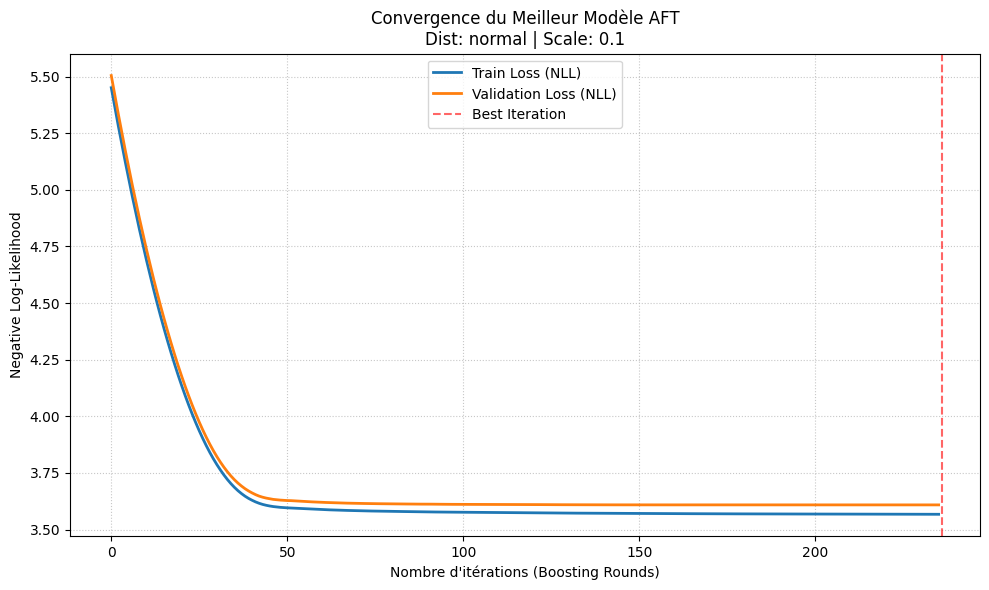

In [433]:

features_aft = features_x + cat_cols  # Features pour le modèle AFT

# Structure de données adaptée pour le modèle AFT
dtrain = xgb.DMatrix(df_train[features_aft])
dtrain.set_float_info('label_lower_bound', df_train['y_lower_log'].values)
dtrain.set_float_info('label_upper_bound', df_train['y_upper_log'].values)

dval = xgb.DMatrix(df_val[features_aft])
dval.set_float_info('label_lower_bound', df_val['y_lower_log'].values)
dval.set_float_info('label_upper_bound', df_val['y_upper_log'].values)

params_aft = {
    'max_depth': [2,4,6],
    'min_child_weight': [1],
    'aft_loss_distribution': ['extreme','logistic', 'normal'],
    'aft_loss_distribution_scale': [0.1, 0.2,0.5, 1.0, 1.20],
    'learning_rate': [0.01, 0.05, 0.1]
}

# On génère toutes les combinaisons possibles (le produit cartésien)
keys, values = zip(*params_aft.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

# Variables pour le suivi du meilleur modèle
best_nloglik = float('inf')
best_params = None
best_history = {} 

print(f"Lancement du tuning sur {len(combinations)} combinaisons...")

for p in tqdm(combinations, desc="Tuning XGB AFT"):
    params = {
        'objective': 'survival:aft',
        'tree_method': 'hist',
        **p
    }
    
    # On crée un dictionnaire pour stocker les scores de cette itération
    evals_result = {}
    
    aft_model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'val')],
        early_stopping_rounds=50,
        evals_result=evals_result,
        verbose_eval=False 
    )
    
    current_score = aft_model.best_score
    
    if current_score < best_nloglik:
        best_nloglik = current_score
        best_params = p
        best_history = evals_result # On sauvegarde l'historique du record
        print(f" Nouveau Record ! Score: {best_nloglik:.4f} | Params: {p}")


# VISUALISATION DE LA COURBE D'APPRENTISSAGE 

plt.figure(figsize=(10, 6))
# 'aft-nloglik' est le nom par défaut de la métrique pour l'objectif survival:aft
train_loss = best_history['train']['aft-nloglik']
val_loss = best_history['val']['aft-nloglik']

plt.plot(train_loss, label='Train Loss (NLL)', color='#1f77b4', lw=2)
plt.plot(val_loss, label='Validation Loss (NLL)', color='#ff7f0e', lw=2)

# On marque l'endroit où l'Early Stopping a arrêté l'entraînement
plt.axvline(x=len(val_loss), color='red', linestyle='--', alpha=0.6, label='Best Iteration')

plt.title(f"Convergence du Meilleur Modèle AFT\nDist: {best_params['aft_loss_distribution']} | Scale: {best_params['aft_loss_distribution_scale']}", fontsize=12)
plt.xlabel("Nombre d'itérations (Boosting Rounds)")
plt.ylabel("Negative Log-Likelihood")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [434]:
# Concaténation train + val
df_trainval = pd.concat([df_train, df_val], ignore_index=True)
dtrainval = xgb.DMatrix(df_trainval[features_aft])
dtrainval.set_float_info('label_lower_bound', df_trainval['y_lower_log'].values)
dtrainval.set_float_info('label_upper_bound', df_trainval['y_upper_log'].values)

# Meilleurs paramètres trouvés
best_params_aft = best_params.copy()
best_params_aft['objective'] = 'survival:aft'
best_params_aft['tree_method'] = 'hist'

# Entraînement final
aft_final_model = xgb.train(
    best_params_aft,
    dtrainval,
    num_boost_round=1000
)

In [435]:
# Prédiction AFT
df_trainval['pred_aft'] = aft_final_model.predict(dtrainval)
dtest = xgb.DMatrix(df_test[features_aft])
df_test['pred_aft'] = aft_final_model.predict(dtest)

In [436]:
y_true_real = np.expm1(df_test['y_lower_log'].values)

from lifelines.utils import concordance_index

c_index = concordance_index(
    event_times=y_true_real,        # durée réelle restante
    predicted_scores=df_test['pred_aft'],    
    event_observed=df_test['evt']    
)

print(f"C-index de test: {c_index:.4f}")

C-index de test: 0.7548


#  Classification avec xgboost

In [437]:
features_binary = features_aft + ['pred_aft']

X_trainval = df_trainval[features_binary]

y_trainval = df_trainval['evt'].astype(int)
X_test = df_test[features_binary]
y_test = df_test['evt'].astype(int) 


Tuning XGB Classifier:   8%|▊         | 1/12 [00:12<02:17, 12.48s/it]

 Nouveau record F1: 0.3247 avec {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 500, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0}


Tuning XGB Classifier:  25%|██▌       | 3/12 [00:28<01:22,  9.19s/it]

 Nouveau record F1: 0.3420 avec {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0}


Tuning XGB Classifier:  58%|█████▊    | 7/12 [01:09<00:52, 10.48s/it]

 Nouveau record F1: 0.3550 avec {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0}


Tuning XGB Classifier:  75%|███████▌  | 9/12 [01:35<00:36, 12.03s/it]

 Nouveau record F1: 0.3552 avec {'max_depth': 6, 'learning_rate': 0.01, 'n_estimators': 500, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0}


Tuning XGB Classifier:  92%|█████████▏| 11/12 [02:02<00:12, 12.67s/it]

 Nouveau record F1: 0.3823 avec {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 0}


Tuning XGB Classifier: 100%|██████████| 12/12 [02:12<00:00, 11.08s/it]


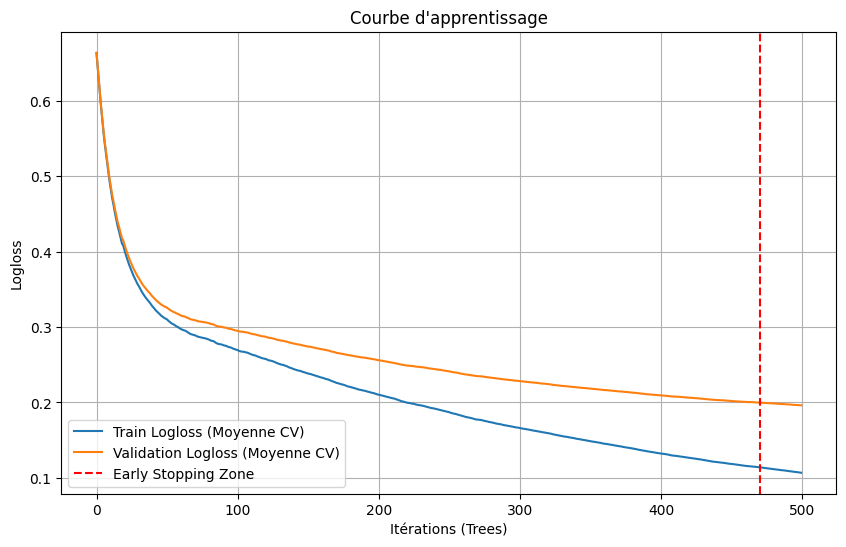

In [438]:
# Classifieur XGBOOST
from itertools import product
param_grid = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [500],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7],
    'gamma': [0]
}

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]



skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Initialisation pour stocker les courbes du meilleur modèle
best_f1 = 0
best_params = None
best_history = [] # Pour stocker les courbes de logloss du meilleur paramétrage

for p in tqdm(combinations, desc="Tuning XGB Classifier"):
    f1_scores = []
    current_params_histories = [] # Historique des 2 splits pour cette combinaison
    
    for train_idx, val_idx in skf.split(X_trainval, y_trainval):
        X_tr, X_va = X_trainval.iloc[train_idx], X_trainval.iloc[val_idx]
        y_tr, y_va = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]
        
        
        clf = XGBClassifier(
            **p,
            scale_pos_weight=(len(y_tr) - y_tr.sum()) / y_tr.sum(),
            eval_metric=['logloss'], 
            random_state=42,
            early_stopping_rounds=30
        )
        
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_tr, y_tr), (X_va, y_va)], 
            verbose=False
        )
        
        # On récupère l'historique de l'entraînement
        current_params_histories.append(clf.evals_result())
        
        y_pred = clf.predict(X_va)
        f1_scores.append(f1_score(y_va, y_pred))
    
    mean_f1 = np.mean(f1_scores)
    
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_params = p
        best_history = current_params_histories
        print(f" Nouveau record F1: {best_f1:.4f} avec {best_params}")

# Visualisation de la courbe d'apprentissage du meilleur modèle

# Calcul de la moyenne des pertes sur les splits pour le meilleur modèle
train_loss_mean = np.mean([h['validation_0']['logloss'] for h in best_history], axis=0)
val_loss_mean = np.mean([h['validation_1']['logloss'] for h in best_history], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(train_loss_mean, label='Train Logloss (Moyenne CV)')
plt.plot(val_loss_mean, label='Validation Logloss (Moyenne CV)')
plt.axvline(x=len(val_loss_mean)-30, color='r', linestyle='--', label='Early Stopping Zone')
plt.title(f"Courbe d'apprentissage")
plt.xlabel('Itérations (Trees)')
plt.ylabel('Logloss')
plt.legend()
plt.grid(True)
plt.show()


In [439]:
# Calcul du scale_pos_weight pour déséquilibre
scale_pos_weight = (len(y_trainval) - y_trainval.sum()) / y_trainval.sum()

# Modèle final
clf_final = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

# Fit sur tout le train
clf_final.fit(X_trainval, y_trainval)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [440]:
# prédiction sur le test 
df_test['prob_lever'] = clf_final.predict_proba(X_test)[:,1]

In [441]:
df_test

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,...,saison_Hiver,saison_Printemps,saison_Été,airport_Ajaccio,airport_Bastia,airport_Biarritz,airport_Nantes,airport_Pise,pred_aft,prob_lever
0,15177,15177,2018-05-14 13:46:33+00:00,8.8303,42.0778,0.156820,0.184,False,0.816721,10.075795,...,0,1,0,1,0,0,0,0,2.164923,0.908583
1,15179,15179,2018-05-14 14:04:45+00:00,8.8630,41.8842,0.187054,0.820,False,-1.453361,123.247809,...,0,1,0,1,0,0,0,0,2.823007,0.730401
2,15183,15183,2018-05-15 03:58:49+00:00,8.7587,41.7525,0.932560,0.235,False,1.259273,194.484472,...,0,1,0,1,0,0,0,0,1.920128,0.658092
3,15823,15823,2018-06-13 13:36:47+00:00,8.7955,42.1022,-0.747606,0.072,False,1.364447,357.627400,...,0,0,1,1,0,0,0,0,2.462950,0.929922
4,15824,15824,2018-06-13 13:39:06+00:00,8.8069,42.0972,-1.021002,0.110,False,1.244727,1.319946,...,0,0,1,1,0,0,0,0,3.176897,0.669516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10711,474197,2189,2016-04-23 19:25:42+00:00,10.5166,43.7252,-0.026391,0.200,False,-0.729167,75.597508,...,0,1,0,0,0,0,0,1,2.116588,0.938924
10712,474200,2192,2016-04-23 19:32:21+00:00,10.5289,43.7277,0.558644,0.400,False,-0.511104,75.870390,...,0,1,0,0,0,0,0,1,3.214676,0.581732
10713,474791,2783,2016-04-24 02:53:09+00:00,10.2036,43.5922,0.500244,0.600,False,1.272989,242.251128,...,0,1,0,0,0,0,0,1,2.618351,0.912331
10714,472059,51,2016-01-12 23:22:46+00:00,10.2899,43.6800,0.746507,1.300,False,-0.963588,262.171568,...,1,0,0,0,0,0,0,1,1.658612,0.944504


In [445]:
SEUIL_FINAL = 0.90 # à ajuster
df_test['lever_alerte_final'] = df_test['prob_lever'] > SEUIL_FINAL
cm  = confusion_matrix(df_test['evt'], df_test['lever_alerte_final'])
print(cm)
print(classification_report(df_test['evt'], df_test['lever_alerte_final']))

[[10235    86]
 [  332    63]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     10321
           1       0.42      0.16      0.23       395

    accuracy                           0.96     10716
   macro avg       0.70      0.58      0.61     10716
weighted avg       0.95      0.96      0.95     10716



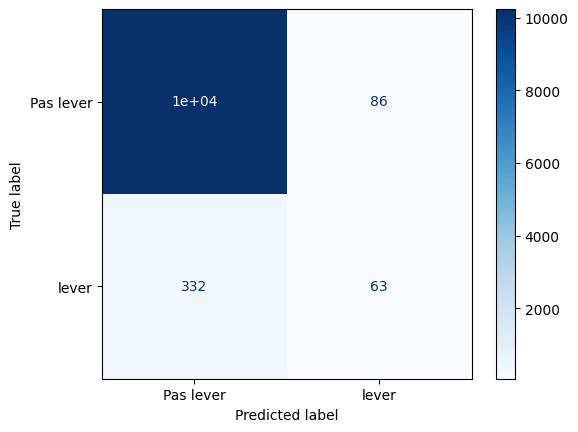

In [446]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pas lever","lever"])
disp.plot(cmap='Blues')

In [447]:
# Calcul de l'AUC
auc_score = roc_auc_score(y_score=df_test['prob_lever'].values, y_true=df_test["evt"])
print(f"AUC: {auc_score:.4f}")

AUC: 0.8894


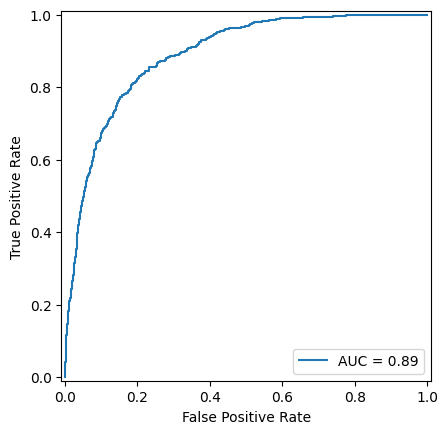

In [448]:
from sklearn.metrics import roc_curve, RocCurveDisplay
fpr, tpr, thresshold = roc_curve(y_score=df_test['prob_lever'].values, y_true=df_test["evt"])
roc = RocCurveDisplay(roc_auc= auc_score, fpr=fpr, tpr = tpr)
roc.plot()


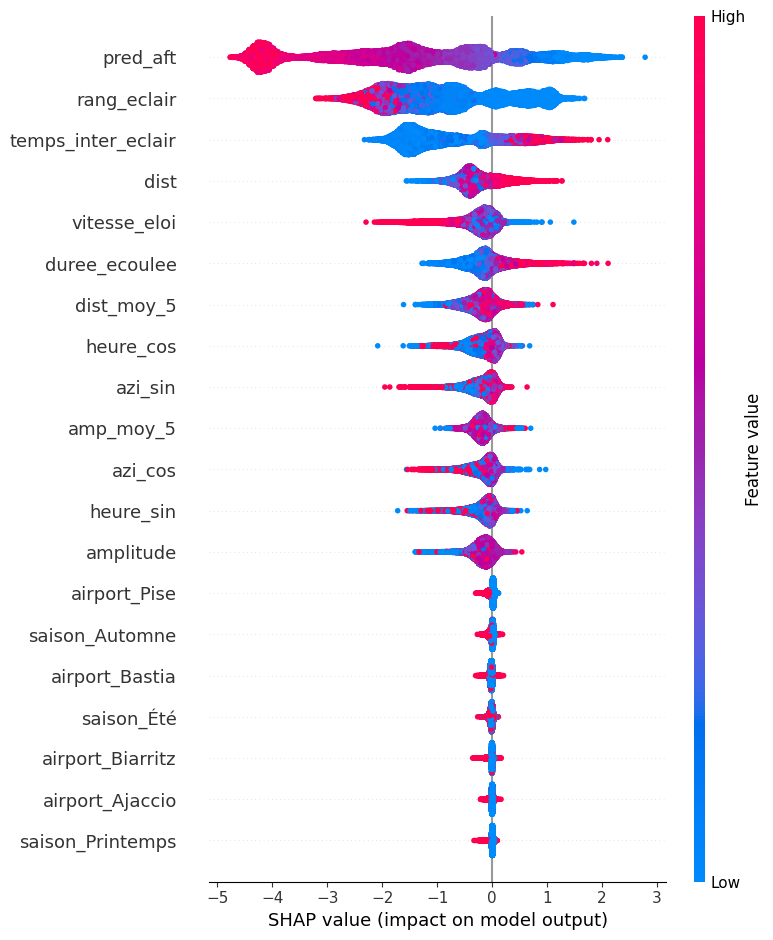

In [449]:
import shap
explainer = shap.TreeExplainer(clf_final)
shap_values = explainer.shap_values(X_trainval)

shap.summary_plot(shap_values, X_trainval)

# Entrainement final

In [421]:

class FlightSafetyFinalEngine:
    def __init__(self, df_brut, features_aft, features_binary, params_aft, params_clf, custom_preprocess_func):
        # Copie locale
        self.df_brut = df_brut.copy()
        
        self.features_aft = features_aft # Variables à utiliser pour le modèle AFT
        self.features_binary = features_binary # Variables à utiliser pour le modèle AFT
        
        self.params_aft = params_aft
        self.params_clf = params_clf
        
        self.preprocess_logic = custom_preprocess_func
        self.aft_model = None
        self.clf_model = None

    def fit_global(self):
        print("Prétraitement...")
        # On s'assure que ton preprocess renvoie une copie propre
        df_ready = self.preprocess_logic(self.df_brut).copy()

        # --- Entraînement AFT ---
        print(f"Entraînement AFT sur {len(df_ready)} lignes ...")
        dmatrix_full = xgb.DMatrix(df_ready[self.features_aft])

        dmatrix_full.set_float_info('label_lower_bound', df_ready['y_lower_log'].values)
        dmatrix_full.set_float_info('label_upper_bound', df_ready['y_upper_log'].values)
        
        self.aft_model = xgb.train(self.params_aft, dmatrix_full, num_boost_round=1000)
        
        # --- Meta-Feature
        df_ready.loc[:, "pred_aft"] = self.aft_model.predict(dmatrix_full)
        
        # --- Classifieur Final ---
        print("Entraînement du Classifieur Final...")
        X_full = df_ready[self.features_binary]
        y_full = df_ready['evt'].astype(int)
        
        # Calcul du poids pour le déséquilibre
        spw = (len(y_full) - y_full.sum()) / y_full.sum()
        
        self.clf_model = XGBClassifier(
            **self.params_clf,
            scale_pos_weight=spw,
            eval_metric='logloss',
            random_state=42
        )
        self.clf_model.fit(X_full, y_full)
        print("Fin!")

    def predict_final(self, df_test_raw):

        df_base_initial = df_test_raw.copy()

        df_work = self.preprocess_logic(df_test_raw).copy()
        
        # Inférence AFT
        dmatrix_test = xgb.DMatrix(df_work[self.features_aft])
        log_preds = self.aft_model.predict(dmatrix_test)
        df_work.loc[:, "pred_aft"] = log_preds
        df_work.loc[:, "predictions"] = np.exp(log_preds)
        
        # Inférence Classifieur
        X_test = df_work[self.features_binary]
        probs = self.clf_model.predict_proba(X_test)[:, 1]
        df_work.loc[:, 'confidence'] = probs

        # --- LE SAUVETAGE DES LIGNES (Jointure) ---
        # On ne garde que les colonnes utiles de df_work pour la fusion

        df_results_only = df_work[['lightning_id', 'predictions', 'confidence']]
        
        # On fusionne la base initiale  avec nos prédictions
        df_final = pd.merge(df_base_initial, df_results_only, on='lightning_id', how='left')
        
        # # Si une ligne a été supprimée, on met 0 
        # df_final['confidence'] = df_final['confidence'].fillna(0)
        # df_final['pred_aft'] = df_final['pred_aft'].fillna(0)
        
        print(f"Fichier reconstruit : {len(df_final)} lignes (Base initiale conservée).")
        return df_final


# Entrainement 

In [422]:
# Entrainement global

engine = FlightSafetyFinalEngine(
    df_brut = df,   
    features_aft = features_aft, 
    features_binary=features_binary, 
    params_aft = best_params_aft,
    params_clf = best_params, 
    custom_preprocess_func = preprocess_isolated
)

engine.fit_global()

Prétraitement...
Entraînement AFT sur 56599 lignes ...


c:\Users\tagossouvo\Desktop\data_train_databattle2026\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:45:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Entraînement du Classifieur Final...
Fin!


# Prédictions 

In [423]:
# --- ÉTAPE FINALE : INFERENCE SUR LES DONNÉES DU TEST

df_données = pd.read_csv('dataset_set.csv')

df_predictions = engine.predict_final(df_données)

df_predictions.dropna()

C:\Users\tagossouvo\AppData\Local\Temp\ipykernel_16436\2332819374.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date"] = pd.to_datetime(df["date"])
C:\Users\tagossouvo\AppData\Local\Temp\ipykernel_16436\2332819374.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['id_final'] = df['airport'].astype(str) + "_" + df['airport_alert_id'].astype(str)
C:\Users\tagossouvo\AppData\Local\Temp\ipykernel_16436\1439829012.py:60: RuntimeWarning: overflow encountered in exp
  df_work.loc[:, "predictions"] =

Fichier reconstruit : 183945 lignes (Base initiale conservée).


,Unnamed: 0,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground,predictions,confidence
26,26,72529,72529,2023-01-17 07:17:34+00:00,8.8989,41.7958,25.14,0.093,False,16.272513,143.087088,Ajaccio,532.0,False,1.000000,0.852975
39,39,72544,72544,2023-01-17 10:52:24+00:00,8.8062,41.9115,-56.56,0.124,False,1.371960,164.744881,Ajaccio,533.0,False,1.000000,0.997849
44,44,72551,72551,2023-01-17 23:47:55+00:00,8.8256,42.0091,-12.51,0.092,False,9.684111,14.868835,Ajaccio,534.0,False,1.000000,0.900620
66,66,72577,72577,2023-03-20 11:04:56+00:00,9.0111,41.8445,-10.90,0.096,False,19.337159,110.802943,Ajaccio,537.0,False,1.000092,0.470198
183,183,72706,72706,2023-05-13 21:26:58+00:00,8.7409,42.0169,-11.87,0.146,False,11.563838,326.395046,Ajaccio,546.0,False,1.000000,0.979662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183884,183884,695176,223168,2025-11-24 14:16:22+00:00,10.3878,43.8252,-7.19,0.117,False,14.495719,355.083434,Pise,1040.0,False,12.898826,0.089749
183888,183888,695180,223172,2025-11-24 14:21:13+00:00,10.3664,43.8154,13.50,1.817,False,13.632310,344.849627,Pise,1040.0,False,6.092379,0.085966
183889,183889,695181,223173,2025-11-24 14:21:14+00:00,10.2244,43.7749,-9.69,0.132,False,16.593549,294.589657,Pise,1040.0,False,51.591721,0.007275
183891,183891,695183,223175,2025-11-24 14:22:35+00:00,10.3678,43.8288,39.36,0.094,False,15.077222,346.874100,Pise,1040.0,False,11.401947,0.104623
